# Banglore House Price Prediction - Project

### Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

### Loading the data

In [5]:
df = pd.read_csv(r"C:\Users\karna\Downloads\archive (12)\Bengaluru_House_Data.csv")

In [6]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [7]:
df.shape

(13320, 9)

In [8]:
print("\nColumns", df.columns)


Columns Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')


In [9]:
# Let's checks each column value counts
for Columns in df.columns:
    print(df[Columns].value_counts())
    print('****' * 10)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
****************************************
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
****************************************
location
Whitefield                        540
Sarjapur  Road                    399
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: i

In [10]:
# Drop these features (to many missing or irrelevnnet)

df = df.drop(['area_type', 'society', 'balcony', 'availability'], axis = 'columns')

In [11]:
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [12]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [13]:
# Droping the rows which are null values

df = df.dropna()

In [14]:
df.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

## EDA

In [16]:
# Convert 'size' to numeric (e.g., '2 BHK' -> 2)

df['bhk'] = df['size'].apply(lambda x : int(x.split(' ')[0]))

In [17]:
df.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


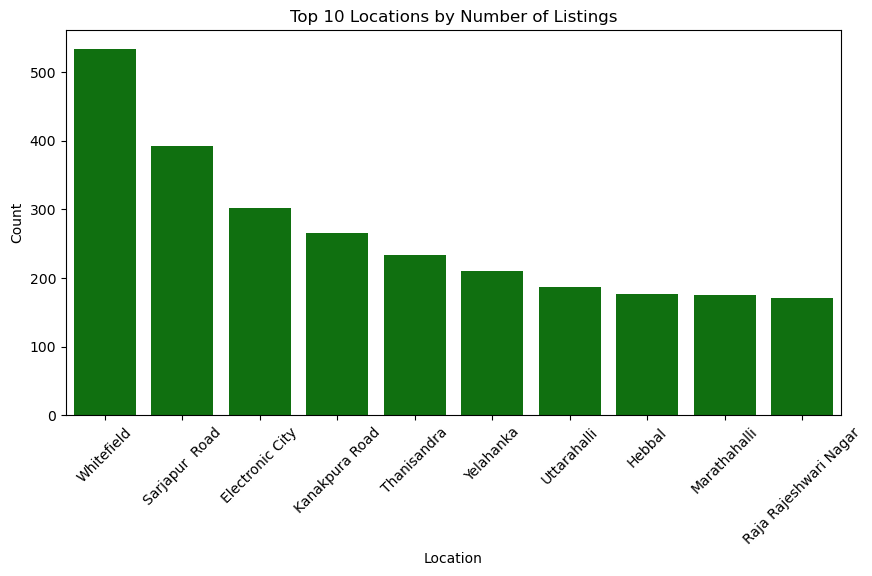

In [18]:
# Top 10 locations with most listings
top_locations = df['location'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x = top_locations.index, y = top_locations.values, color = 'green')
plt.xticks(rotation=45)
plt.title('Top 10 Locations by Number of Listings')
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()

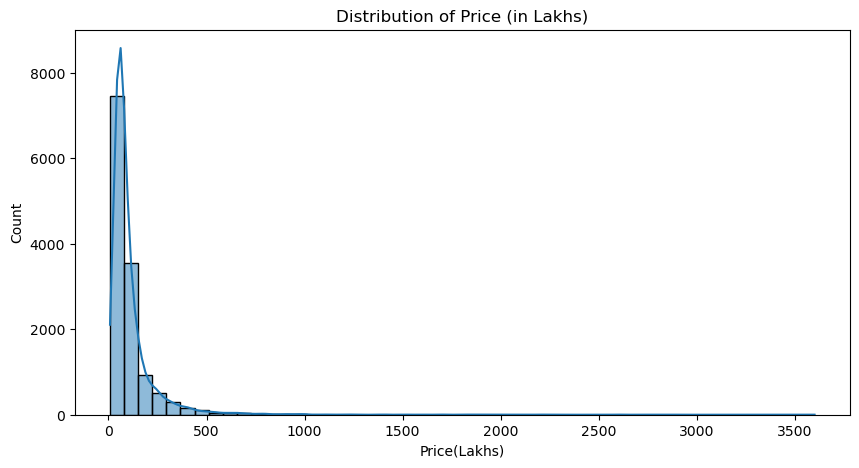

In [19]:
# Distribution of price
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins = 50, kde = True)
plt.title('Distribution of Price (in Lakhs)')
plt.xlabel('Price(Lakhs)')
plt.ylabel('Count')
plt.show()

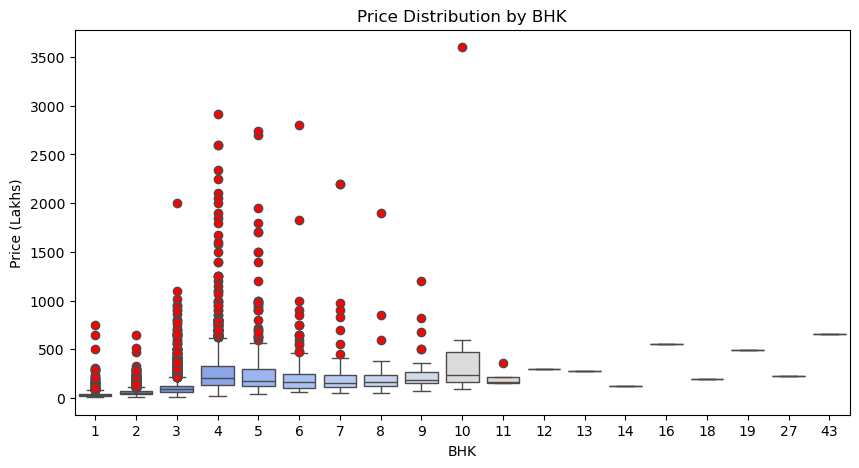

In [20]:
# Boxplot: Price vs BHK
plt.figure(figsize=(10, 5))
sns.boxplot(x = 'bhk', y='price', data=df,
           palette='coolwarm', showfliers=True,flierprops=dict(marker = 'o',
                                             markerfacecolor='red',
                                             markersize='6',
                                             linestyle='none'))
plt.title('Price Distribution by BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.show()

In [21]:
df.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [22]:
df.shape

(13246, 6)

## Feature Engineering and Data Cleaning

In [24]:
df['total_sqft'].sample(20)

113      1530
294      1005
11812    1344
1519      600
10060    1738
7844     1693
6894     1025
1534     2400
2177     1200
5349     2100
3458     1665
4814     1550
2647     1071
2544     1870
700      1125
2160     1375
5756     1090
6354     1200
6783     1200
9901     1320
Name: total_sqft, dtype: object

In [25]:
# Convert 'total_sqft' to a single numeric value
def convert_sqft_to_num(x):
    try:
        x = str(x)
        tokens = x.split('-')
        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

# Drop rows with invalid or null 'total_sqft'
df = df.dropna(subset=['total_sqft'])

print("After sqft conversion:", df.shape)

After sqft conversion: (13200, 6)


## Calculating Price per Square Foot

In [27]:
# Add new column: price per square foot
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

In [28]:
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [29]:
# Clean 'location' text
df['location'] = df['location'].apply(lambda x:x.strip())

# Group rare locations as 'other'
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

print("Unique locations:", len(df['location'].unique()))

Unique locations: 241


## Removing Unrealistically Small BHK Configurations

In [31]:
# remove rows where total_sqft per BHK is less tan 300

df = df[df['total_sqft'] / df['bhk'] >= 300]

print("After removing low sqft per BHK:", df.shape)

After removing low sqft per BHK: (12456, 7)


In [32]:
## Remove Locations-Wise Price per Sqft outliers

def remove_pps_outliers(df):
    cleaned_df = pd.DataFrame()

    for loaction, group in df.groupby('locations'):
        mean = group['price_per_sqft'].mean()
        std = group['price_per_sqft'].std()

        filtered = group[(group['price_per_sqft'] > (mean - std)) &
                 (group['price_per_sqft'] <= (mean + std))]

        cleaned_df = pd.concat([cleaned_df, filtered], ignore_index=True)
    return cleaned_df
 # Apply the function to clean the dataset
    df = remove_pps_outliers(df)

print("After removing price_per_sqft outliers:", df.shape)

After removing price_per_sqft outliers: (12456, 7)


In [33]:
# This function removes BHK-Basd pricing outliers for each location

def remove_bhk_outliers(df):
    indices_to_remove = []

    for location, location_df in df.groupby("location"):
        bhk_price_stats = {}

        # Step 1: Calculate stats
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_price_stats[bhk] = {
                'mean_price': bhk_df['price_per_sqft'].mean(),
                'std_dev': bhk_df['price_per_sqft'].std(),
                'count': bhk_df.shape[0]
            }

        # Step 2: Compare with lower BHK
        for bhk, bhk_df in location_df.groupby('bhk'):
            lower_bhk_stats = bhk_price_stats.get(bhk - 1)

            if lower_bhk_stats and lower_bhk_stats['count'] > 5:
                bad_bhk = bhk_df[
                    bhk_df['price_per_sqft'] < lower_bhk_stats['mean_price']
                ]
                indices_to_remove.extend(bad_bhk.index)

    return df.drop(indices_to_remove, axis='index')


# Apply function
df = remove_bhk_outliers(df)

print("After removing BHK outliers:", df.shape)

After removing BHK outliers: (8638, 7)


## Remove Unrealistic  Bathroom Counts

In [35]:
# Keep rows where number of bathrooms is reasonable
df = df[df['bath'] < df['bhk'] + 2]

print("After removings bathroom outliers:", df.shape)

After removings bathroom outliers: (8508, 7)


## Dropping Unnecessary Columns for Modeling

In [37]:
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467.057101


In [38]:
df_model = df.drop(['size', 'price_per_sqft'], axis=1)
df_model.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2
6,Old Airport Road,2732.0,4.0,204.00,4


## One-Hot Encode Locations Column

In [40]:
df['location'].unique

<bound method Series.unique of 0        Electronic City Phase II
2                     Uttarahalli
3              Lingadheeranahalli
4                        Kothanur
6                Old Airport Road
                   ...           
13314           Green Glen Layout
13316                       other
13317       Raja Rajeshwari Nagar
13318             Padmanabhanagar
13319                Doddathoguru
Name: location, Length: 8508, dtype: object>

In [41]:
dummies = pd.get_dummies(df_model['location'], dtype=int)
df_model = pd.concat([df_model.drop('location', axis=1), dummies.drop('other', axis=1)], axis=1)

print("Final shape after encoding:", df_model.shape)

Final shape after encoding: (8508, 244)


## Train Test Split

In [43]:
X = df_model.drop('price', axis = 1)
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (6806, 243)
X_test shape: (1702, 243)


## Linear Regression

In [45]:
# train the model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, y_pred)

print("📉 Linear Regression R2 Score:", round(lr_r2, 3))

📉 Linear Regression R2 Score: 0.686


## RandomForest Regressor

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Train model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_rf = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest R2 Score:", round(rf_r2, 3))

Random Forest R2 Score: 0.757


## XgBoost Regressor

In [49]:
from  xgboost import XGBRegressor
from sklearn.metrics import r2_score

xgb_model  = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost R2 Score:", round(xgb_r2, 3))

XGBoost R2 Score: 0.767


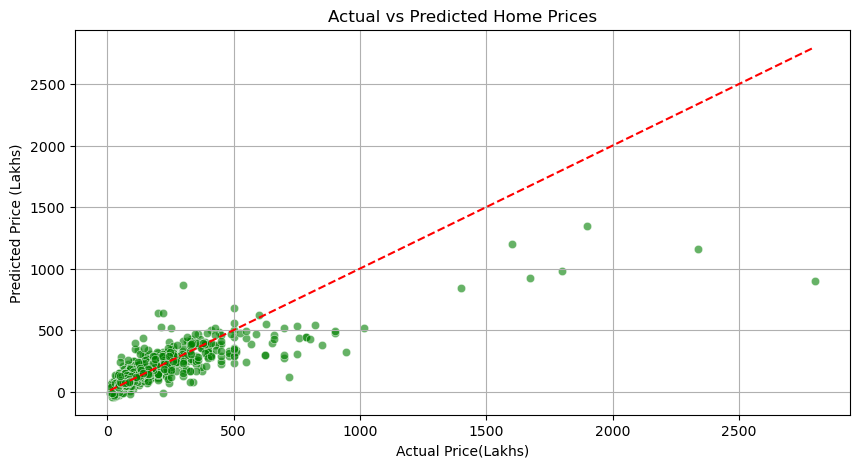

In [50]:
# scatter plot of Actual vs Predicted

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r') # Diagonal line
plt.title('Actual vs Predicted Home Prices')
plt.xlabel('Actual Price(Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.grid(True)
plt.show()

## saving the model

In [52]:
import joblib

joblib.dump(lr_model, 'lineaer_regression_model.pkl')

# Load the model
# loaded_model = joblib.load('linear_regression_model.pkl')

['lineaer_regression_model.pkl']